Import Necessary Libraries

In [17]:
# Necessary imports for data processing and model training
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from scipy.stats import randint as sp_randint

Load Dataset

In [16]:
# Load the cleaned dataset
df = pd.read_csv('./cleaned_cyberbullying_tweets.csv')
df.head()

,text_clean,sentiment_encoded
0,word katandandre food crapilicious mkr,3
1,aussietv white mkr theblock imacelebrityau tod...,3
2,classy whore red velvet cupcake,3
3,meh thanks head concerned another angry dude t...,3
4,isi account pretending kurdish account like is...,3


Train the Baseline Model

In [21]:
# Define the input and target variables
X = df['text_clean']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a baseline pipeline (without hyperparameter tuning)
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('lr', LogisticRegression(max_iter=500, random_state=42))  # Logistic Regression classifier with more iterations
])

# Train the baseline model
baseline_pipeline.fit(X_train, y_train)

# Save the baseline model
joblib.dump(baseline_pipeline, 'logistic_regression_baseline_model.pkl')

['logistic_regression_baseline_model.pkl']

Evaluate the Baseline Model's Performance

Classification Report for Baseline Model:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1552
           1       0.98      0.99      0.98      1538
           2       0.95      0.88      0.91      1459
           3       0.80      0.84      0.82      1291
           5       0.96      0.95      0.96      1566

    accuracy                           0.93      7406
   macro avg       0.93      0.93      0.93      7406
weighted avg       0.93      0.93      0.93      7406

Confusion Matrix for Baseline Model:


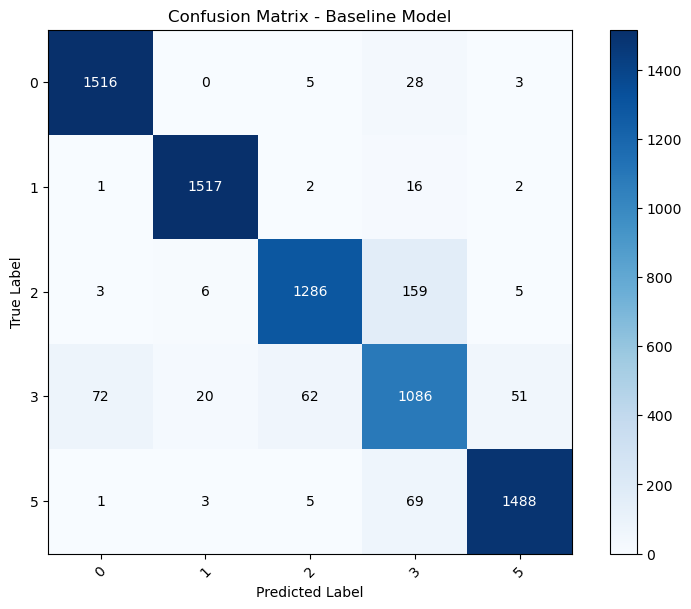

Baseline Model - Cross Validation Scores: [0.93424251 0.92653612 0.92802161 0.92991222 0.92748143]
Baseline Model - Mean Cross Validation Score: 0.9292387780552038


In [22]:
# Predict on the test set using the baseline model
y_pred_baseline = baseline_pipeline.predict(X_test)

# Classification report for the baseline model
print("Classification Report for Baseline Model:")
print(classification_report(y_test, y_pred_baseline))

# Confusion matrix for the baseline model
print("Confusion Matrix for Baseline Model:")
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

# Plot the confusion matrix for the baseline model
plt.figure(figsize=(8, 6))
plt.imshow(cm_baseline, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Baseline Model')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test), rotation=45)
plt.yticks(tick_marks, np.unique(y_test))

# Annotate each cell with its value
thresh = cm_baseline.max() / 2.
for i in range(cm_baseline.shape[0]):
    for j in range(cm_baseline.shape[1]):
        plt.text(j, i, format(cm_baseline[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm_baseline[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Cross-validation score for the baseline model
cv_scores_baseline = cross_val_score(baseline_pipeline, X, y, cv=5)
print("Baseline Model - Cross Validation Scores:", cv_scores_baseline)
print("Baseline Model - Mean Cross Validation Score:", cv_scores_baseline.mean())

Hyperparameter Tuning with GridSearchCV

In [24]:
# Define the hyperparameter grid for GridSearchCV
param_grid = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],         # TF-IDF max document frequency
    'tfidf__min_df': [1, 2, 5],                     # TF-IDF min document frequency
    'tfidf__ngram_range': [(1, 1), (1, 2)],         # Unigrams and bigrams
    'lr__C': [0.01, 0.1, 1, 10, 100],               # Regularization strength for Logistic Regression
    'lr__solver': ['liblinear', 'lbfgs', 'saga'],    # Solvers to try
    'lr__max_iter': [100, 200, 300]                 # Maximum iterations for solver
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    baseline_pipeline,           # The previously defined pipeline
    param_grid,                  # Hyperparameter grid to search over
    cv=5,                        # 5-fold cross-validation
    n_jobs=-1,                   # Use all available cores for faster computation
    verbose=1                    # Print detailed output during grid search
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the best cross-validation score
print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score (GridSearchCV):", grid_search.best_score_)

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits
Best parameters from GridSearchCV: {'lr__C': 10, 'lr__max_iter': 100, 'lr__solver': 'liblinear', 'tfidf__max_df': 0.7, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (GridSearchCV): 0.9300810263335583


Hyperparameter Tuning with RandomizedSearchCV

In [23]:
# Define the hyperparameter distributions for RandomizedSearchCV
param_dist = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],            # TF-IDF max document frequency
    'tfidf__min_df': sp_randint(1, 10),                # Randomly sample TF-IDF min document frequency
    'tfidf__ngram_range': [(1, 1), (1, 2)],             # Unigrams and bigrams
    'lr__C': sp_randint(1, 100),                        # Regularization strength with random distribution
    'lr__solver': ['liblinear', 'lbfgs', 'saga'],       # Solvers to try
    'lr__max_iter': sp_randint(100, 500)                # Randomize the maximum iterations
}

# Set up RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(
    baseline_pipeline,                         # The pipeline with TfidfVectorizer and Logistic Regression
    param_distributions=param_dist,            # Hyperparameter distributions to sample from
    n_iter=20,                                 # Number of parameter settings sampled
    cv=5,                                      # 5-fold cross-validation
    n_jobs=-1,                                 # Use all available cores for faster computation
    verbose=1,                                 # Print detailed output during randomized search
    random_state=42                            # Ensures reproducibility
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best hyperparameters and the best cross-validation score
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score (RandomizedSearchCV):", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV: {'lr__C': 3, 'lr__max_iter': 249, 'lr__solver': 'liblinear', 'tfidf__max_df': 0.8, 'tfidf__min_df': 8, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (RandomizedSearchCV): 0.9308237677245105


Save the Best Model

In [25]:
# Save the best model
# joblib.dump(grid_search.best_estimator_, 'logistic_regression_best_grid.pkl')
joblib.dump(random_search.best_estimator_, 'logistic_regression_best_random.pkl')

['logistic_regression_best_random.pkl']

Evaluate the Best Model's Performance

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1552
           1       0.99      0.99      0.99      1538
           2       0.94      0.89      0.91      1459
           3       0.81      0.84      0.83      1291
           5       0.96      0.95      0.96      1566

    accuracy                           0.93      7406
   macro avg       0.93      0.93      0.93      7406
weighted avg       0.93      0.93      0.93      7406

Confusion Matrix for Best Model:


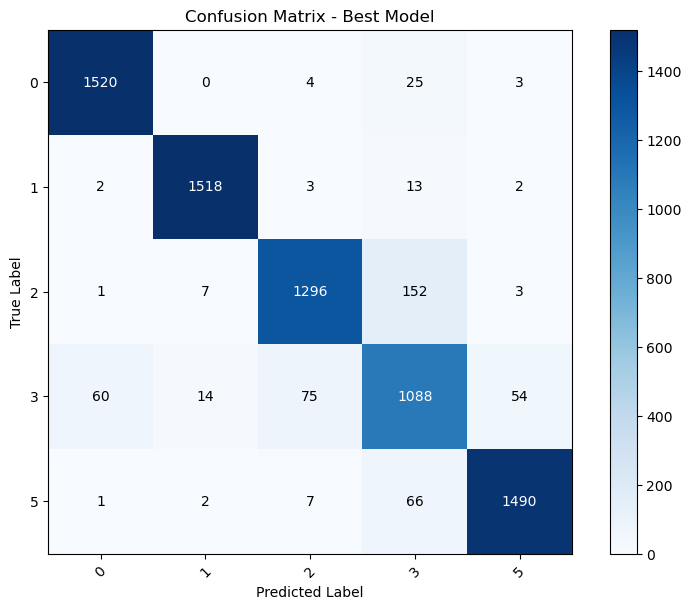

Best Model - Cross Validation Scores: [0.93667297 0.93004727 0.93018231 0.93288319 0.92842674]
Best Model - Mean Cross Validation Score: 0.9316424936403008


In [27]:
# Use the best model make predictions on the test set
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

# Generate the classification report
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred_best))

# Confusion matrix for the best model
print("Confusion Matrix for Best Model:")
cm_best = confusion_matrix(y_test, y_pred_best)

# Plot the confusion matrix for the best model
plt.figure(figsize=(8, 6))
plt.imshow(cm_best, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Best Model')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test), rotation=45)
plt.yticks(tick_marks, np.unique(y_test))

# Annotate each cell with its value
thresh = cm_best.max() / 2.
for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, format(cm_best[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm_best[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Cross-validation score for the best model
cv_scores_best = cross_val_score(best_model, X, y, cv=5)
print("Best Model - Cross Validation Scores:", cv_scores_best)
print("Best Model - Mean Cross Validation Score:", cv_scores_best.mean())

Test the Model with a New Piece of Text

In [28]:
# Load the saved Logistic Regression model
loaded_model = joblib.load('logistic_regression_best_random.pkl')

# Define a new piece of text to classify
new_text = "Son of bitch"

# Predict the sentiment of the new text
prediction = loaded_model.predict([new_text])

# Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: Son of bitch
Predicted Sentiment: 2
